In [1]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import cv2


In [3]:
# Define a function to preprocess the images 
def process_image(image_path):
    
    image_path = image_path.replace("E:\\TARUN\\Projects\\Autism Detection\\Data\\data_png",'/kaggle/input/autism/')
    image_path = image_path.replace("\\",'/')
    
    # Read the original image
    original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply Canny edge detection
    edges = cv2.Canny(original_image, threshold1=30, threshold2=100)  # Adjust thresholds as needed

    # Find the contours of the edges
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour (the edges of the MRI structure)
    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Crop the image based on the largest contour
        cropped_image = original_image[y:y+h, x:x+w]

    else:
        # If no contours are found, set cropped_image to the original image
        cropped_image = original_image

    # Resize to the desired image size (224x224)
    image_size = (224, 224)
    cropped_image = cv2.resize(cropped_image, image_size)

    # Convert single-channel image to RGB
    cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_GRAY2RGB)

    # Min-Max Normalization
    min_value = 0
    max_value = 255
    cropped_image = (cropped_image - min_value) / (max_value - min_value)

    return cropped_image


In [4]:
class CustomDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.process_image = process_image

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_path = self.data.iloc[index, 1]  # 'Image_paths' is the column containing file paths
        processed_image = self.process_image(img_path)
        label = int(self.data.iloc[index, 3])  # 'LABEL' is the column containing labels (0 or 1)
        
        # Convert to torch tensor
        image_tensor = torch.from_numpy(processed_image.transpose((2, 0, 1))).float()
        
        return image_tensor, label
    

In [5]:
# Define batch size
batch_size = 32

# Create train and test data loaders
train_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_train.csv')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_test.csv')
test_loader = DataLoader(test_dataset, batch_size=batch_size)

val_dataset = CustomDataset('/kaggle/input/autism-csv/extracted_random_labels_validation.csv')
val_loader = DataLoader(val_dataset, batch_size=batch_size)


In [6]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Test dataset size: {len(val_dataset)}")


Train dataset size: 72367
Test dataset size: 20102
Test dataset size: 8041


In [7]:
import torch

def patchify(image, patch_size):
    # Get the dimensions of the image
    _, height, width = image.size()

    # Calculate the number of patches in each dimension
    num_patches_h = height // patch_size
    num_patches_w = width // patch_size

    # Initialize an empty list to store the patches
    patches = []

    # Iterate over the image and extract patches
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            # Calculate the starting and ending indices of the patch
            start_h = i * patch_size
            end_h = start_h + patch_size
            start_w = j * patch_size
            end_w = start_w + patch_size

            # Extract the patch from the image
            patch = image[:, start_h:end_h, start_w:end_w]

            # Append the patch to the list
            patches.append(patch)

    # Convert the list of patches into a PyTorch tensor
    patches = torch.stack(patches)

    return patches


In [8]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, embed_dim, patch_size, num_patches, dropout, in_channels):
        super().__init__()

        self.patcher = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=embed_dim,
                kernel_size=patch_size,
                stride=patch_size,
            ),
            nn.Flatten(2)
        )

        self.cls_token = nn.Parameter(torch.randn(size=(1, 1, embed_dim)), requires_grad=True)
        self.position_embeddings = nn.Parameter(torch.randn(size=(1, num_patches+1, embed_dim)), requires_grad=True)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        cls_token = self.cls_token.expand(x.shape[0], -1, -1)
        x = self.patcher(x).permute(0, 2, 1)
        x = torch.cat([cls_token, x], dim=1)
        x = self.position_embeddings + x
        x = self.dropout(x)
        return x


In [9]:
import torch
import torch.nn as nn

class ViT(nn.Module):
    def __init__(self, num_patches, img_size, num_classes, patch_size, embed_dim, num_encoders, num_heads, hidden_dim, dropout, activation, in_channels):
        super().__init__()

        # Patch Embedding layer
        self.embeddings_block = PatchEmbedding(embed_dim, patch_size, num_patches, dropout, in_channels)

        # Transformer Encoder blocks
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dropout=dropout, activation=activation, batch_first=True, norm_first=True)
        self.encoder_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_encoders)

        # MLP Head for classification with Batch Normalization for spatial features
        self.mlp_head = nn.Sequential(
            nn.BatchNorm1d(num_features=embed_dim),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=embed_dim, out_features=num_classes)
        )

    def forward(self, x):
        # Forward pass through the model components
        x = self.embeddings_block(x)
        x = self.encoder_blocks(x)
        x = self.mlp_head(x[:, 0, :])  # Apply MLP on the CLS token only
        return x


In [8]:
import torch
import torch.nn as nn

class ViT(nn.Module):
    def __init__(self, num_patches, img_size, num_classes, patch_size, embed_dim, num_encoders, num_heads, hidden_dim, dropout, activation, in_channels):
        super().__init__()

        # Patch Embedding layer
        self.embeddings_block = PatchEmbedding(embed_dim, patch_size, num_patches, dropout, in_channels)

        # Transformer Encoder blocks
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dropout=dropout, activation=activation, batch_first=True, norm_first=True)
        self.encoder_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_encoders)

        # MLP Head for classification with Batch Normalization for spatial features
        self.mlp_head = nn.Sequential(
        nn.BatchNorm1d(num_features=embed_dim),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=embed_dim, out_features=hidden_dim),  # Adjust hidden layer size
        nn.GELU(),
        nn.Linear(in_features=hidden_dim, out_features=num_classes)
        )

    def forward(self, x):
        # Forward pass through the model components
        x = self.embeddings_block(x)
        x = self.encoder_blocks(x)
        x = self.mlp_head(x[:, 0, :])  # Apply MLP on the CLS token only
        return x


In [10]:
# Check if a GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [11]:
import torch
import torch.nn as nn

# Parameters
NUM_PATCHES = 196  # Assuming a 14x14 grid of patches for a 224x224 image and patch size of 16x16
IMG_SIZE = 224
NUM_CLASSES = 2  # Adjust as needed
PATCH_SIZE = 16  # Adjust this based on the desired patch size
EMBED_DIM = 64
NUM_ENCODERS = 6
NUM_HEADS = 4
HIDDEN_DIM = 128
DROPOUT = 0.2
ACTIVATION = 'gelu'
IN_CHANNELS = 3  # Three channels for RGB images

# Instantiate the ViT model
vit_model = ViT(
    num_patches=NUM_PATCHES,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    num_encoders=NUM_ENCODERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    activation=ACTIVATION,
    in_channels=IN_CHANNELS
)
vit_model = vit_model.to(device)

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [15]:
pip install torchinfo


Note: you may need to restart the kernel to use updated packages.


In [17]:
from torchinfo import summary

# Move the model to the device
vit_model = vit_model.to(device)

# Print the model summary
summary(vit_model, input_size=(batch_size, IN_CHANNELS, IMG_SIZE, IMG_SIZE), device=device.type)


Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [32, 2]                   --
├─PatchEmbedding: 1-1                         [32, 197, 64]             12,672
│    └─Sequential: 2-1                        [32, 64, 196]             --
│    │    └─Conv2d: 3-1                       [32, 64, 14, 14]          49,216
│    │    └─Flatten: 3-2                      [32, 64, 196]             --
│    └─Dropout: 2-2                           [32, 197, 64]             --
├─TransformerEncoder: 1-2                     [32, 197, 64]             --
│    └─ModuleList: 2-3                        --                        --
│    │    └─TransformerEncoderLayer: 3-3      [32, 197, 64]             281,152
│    │    └─TransformerEncoderLayer: 3-4      [32, 197, 64]             281,152
│    │    └─TransformerEncoderLayer: 3-5      [32, 197, 64]             281,152
│    │    └─TransformerEncoderLayer: 3-6      [32, 197, 64]             

In [11]:
import torch.nn as nn

# Assuming you have multiple classes
num_classes = 2  

# Use Categorical Cross-Entropy Loss
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)  # Move the criterion to the device (e.g., GPU) if applicable


In [12]:
import torch.optim as optim

# Define the hyperparameters
learning_rate = 0.0001  # η
beta1 = 0.9  # β1
beta2 = 0.999  # β2
epsilon = 1e-7  # ε

# Create an instance of the Adam optimizer with weight decay
optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate, betas=(beta1, beta2), eps=epsilon)


In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 0  # Change this to the epoch you want to continue from

num_epochs = 50  # Set the total number of epochs you want to run

for epoch in range(current_epoch, num_epochs):
    vit_model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = vit_model(images)
        
        # For multi-class classification, labels should be of type torch.long
        labels = labels.long()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    vit_model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        outputs = vit_model(images)
        
        # For multi-class classification, labels should be of type torch.long
        labels = labels.long()

        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    torch.save(vit_model.state_dict(), '/kaggle/working/4_64_128_6_weights_1.pth')
    
    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('Finished Training')


Epoch 1/50 (Validation): 100%|██████████| 252/252 [01:11<00:00,  3.51it/s]


Epoch [1/50], Training Loss: 0.6934, Training Accuracy: 0.5221
Validation Loss: 0.6920, Validation Accuracy: 0.5319


Epoch 2/50 (Validation): 100%|██████████| 252/252 [00:36<00:00,  6.94it/s]


Epoch [2/50], Training Loss: 0.6896, Training Accuracy: 0.5386
Validation Loss: 0.6905, Validation Accuracy: 0.5397


Epoch 3/50 (Validation): 100%|██████████| 252/252 [00:36<00:00,  6.85it/s]


...

Epoch 21/50 (Validation): 100%|██████████| 252/252 [00:36<00:00,  6.95it/s]


Epoch [21/50], Training Loss: 0.6674, Training Accuracy: 0.5852
Validation Loss: 0.6679, Validation Accuracy: 0.5913


Epoch 22/50 (Validation): 100%|██████████| 252/252 [00:36<00:00,  6.99it/s]


Epoch [22/50], Training Loss: 0.6666, Training Accuracy: 0.5847
Validation Loss: 0.6686, Validation Accuracy: 0.5870


Epoch 24/50 (Training):  44%|████▍     | 999/2262 [03:03<03:42,  5.68it/s]]

In [ ]:
#Training vs Validation accuracies
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_accuracies))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_accuracies[:min_epochs], label='Train_Accuracy', marker='o')
plt.plot(range(1, min_epochs + 1), val_accuracies[:min_epochs], label='Val_Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs. Validation Accuracies')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Training vs Validation loss
import matplotlib.pyplot as plt

# Find the minimum number of epochs (between num_epochs and the number of epochs actually completed)
min_epochs = min(num_epochs, len(train_losses))

plt.figure(figsize=(6, 4))
plt.plot(range(1, min_epochs + 1), train_losses[:min_epochs], label='Train_Loss', marker='o')
plt.plot(range(1, min_epochs + 1), val_losses[:min_epochs], label='Val_Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.grid(True)
plt.show()

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

vit_model.load_state_dict(torch.load('/kaggle/input/4_64_128_6_weights_1.pth'))

# Create empty lists to store training and validation losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Set the current epoch number to continue from where you left off
current_epoch = 50  # Change this to the epoch you want to continue from

num_epochs = 100  # Set the total number of epochs you want to run

for epoch in range(current_epoch, num_epochs):
    vit_model.train()
    running_train_loss = 0.0
    train_preds = []
    train_targets = []

    # Training loop with a progress bar
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Training)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = vit_model(images)
        
        # For multi-class classification, labels should be of type torch.long
        labels = labels.long()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_preds.extend(predicted.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    # Calculate and print the average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Calculate training accuracy for this epoch
    train_accuracy = accuracy_score(train_targets, train_preds)
    train_accuracies.append(train_accuracy)

    vit_model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    val_preds = []
    val_targets = []

    # Validation loop with a progress bar
    for images, labels in tqdm(val_loader, desc=f'Epoch {epoch + 1}/{num_epochs} (Validation)'):
        images, labels = images.to(device), labels.to(device)  # Move data to GPU
        outputs = vit_model(images)
        
        # For multi-class classification, labels should be of type torch.long
        labels = labels.long()

        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        val_preds.extend(predicted.cpu().numpy())
        val_targets.extend(labels.cpu().numpy())

    # Calculate and print the average validation loss for this epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy for this epoch
    val_accuracy = accuracy_score(val_targets, val_preds)
    val_accuracies.append(val_accuracy)

    torch.save(vit_model.state_dict(), '/kaggle/working/4_64_128_6_weights_2.pth')
    
    # Print loss and accuracy for this epoch
    print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('Finished Training')


In [16]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# Load the trained model weights
#vit_model.load_state_dict(torch.load('/kaggle/working/vit_weights.pth'))
#vit_model.eval()  # Set the model to evaluation mode

# Initialize variables for evaluation
test_preds = []
test_targets = []

# Test loop
for images, labels in tqdm(test_loader, desc='Testing'):
    images, labels = images.to(device), labels.to(device)  # Move data to GPU
    outputs = vit_model(images)
    
    # For multi-class classification, labels should be of type torch.long
    labels = labels.long()

    _, predicted = torch.max(outputs, 1)
    test_preds.extend(predicted.cpu().numpy())
    test_targets.extend(labels.cpu().numpy())

# Calculate metrics
conf_matrix = confusion_matrix(test_targets, test_preds)
precision = precision_score(test_targets, test_preds, average='weighted')
recall = recall_score(test_targets, test_preds, average='weighted')
f1 = f1_score(test_targets, test_preds, average='weighted')

# Calculate sensitivity and specificity
tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(test_targets, test_preds)
roc_auc = auc(fpr, tpr)

# Print the metrics
print(f'Accuracy: {accuracy_score(test_targets, test_preds):.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')


Testing: 100%|██████████| 315/315 [03:39<00:00,  1.43it/s]

Accuracy: 0.7672

Precision: 0.7680

Recall: 0.7672

F1 Score: 0.7673

Sensitivity: 0.7796

Specificity: 0.7557


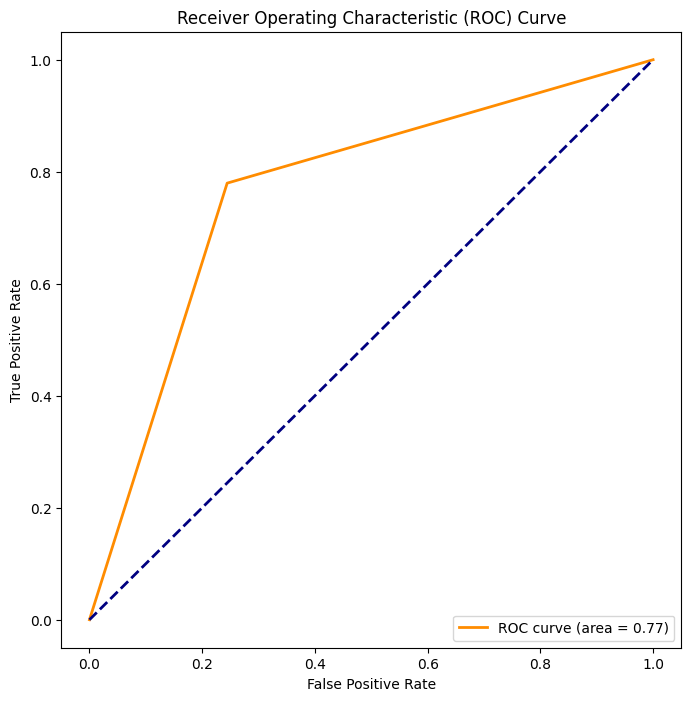

In [17]:
# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
# Print confusion matrix
print('Confusion Matrix:')
print(conf_matrix)


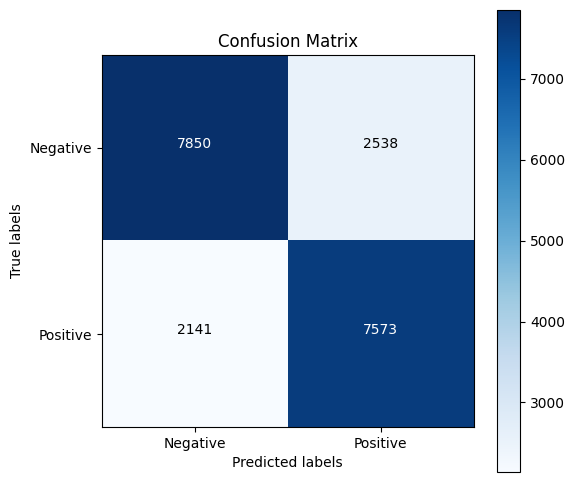

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming conf_matrix is your confusion matrix
# Replace it with the actual confusion matrix obtained from your model evaluation
conf_matrix = np.array([[tn, fp], [fn, tp]])

# Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate cells with their values
thresh = conf_matrix.max() / 2.0  # Set a threshold for text coloring
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

# Set axis labels and ticks
class_labels = ['Negative', 'Positive']
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(len(class_labels)), class_labels)
plt.yticks(np.arange(len(class_labels)), class_labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()
